In [1]:
import requests
import pandas as pd

In [ ]:
TOKEN = "INSERT_YOUR_ESIOS_TOKEN"

In [3]:

headers = {
    "Accept": "application/json",
    "Content-Type": "application/json",
    "Host": "api.esios.ree.es",
    "x-api-key": TOKEN
}

url = "https://api.esios.ree.es/indicators"

response = requests.get(url, headers=headers)

print(response.status_code)

200


## Descarga de precios PVPC mediante API e·sios

En esta fase se realiza la conexión con la API oficial de e·sios para obtener precios eléctricos horarios asociados al PVPC. El token utilizado es personal y no debe compartirse públicamente. Siguiendo las recomendaciones de REE, los datos descargados se almacenarán localmente para evitar peticiones redundantes a la API.


In [4]:
data = response.json()

indicators = data["indicators"]

pvpc_indicators = [
    {
        "id": item["id"],
        "name": item["name"],
        "short_name": item.get("short_name", "")
    }
    for item in indicators
    if "PVPC" in item["name"].upper() or "PVPC" in item.get("short_name", "").upper()
]

pd.DataFrame(pvpc_indicators)

,id,name,short_name
0,526,Perfiles de consumo a efectos de facturación d...,Tarifa 2.0.A (peaje por defecto)
1,527,Perfiles de consumo a efectos de facturación d...,Tarifa 2.0.DHA (Eficiencia 2 periodos)
2,528,Perfiles de consumo a efectos de facturación d...,Tarifa 2.0.DHS (vehículo eléctrico)
3,1001,Término de facturación de energía activa del P...,PVPC T. 2.0TD
4,1002,Periodo Tarifario del PVPC 2.0TD,Periodo T. 2.0TD
5,1003,Término de facturación de energía activa del P...,PVPC T. 2.0TD P1
6,1004,Término de facturación de energía activa del P...,PVPC T. 2.0TD P2
7,1005,Término de facturación de energía activa del P...,PVPC T. 2.0TD P3
8,1006,Perfiles de consumo a efectos de facturación d...,Tarifa 2.0TD
9,1013,Término de facturación de energía activa del P...,PVPC T. Defecto


In [5]:
import time

months = [
    ("2023-01-01", "2023-01-31"),
    ("2023-02-01", "2023-02-28"),
    ("2023-03-01", "2023-03-31"),
    ("2023-04-01", "2023-04-30"),
    ("2023-05-01", "2023-05-31"),
    ("2023-06-01", "2023-06-30"),
    ("2023-07-01", "2023-07-31"),
    ("2023-08-01", "2023-08-31"),
    ("2023-09-01", "2023-09-30"),
    ("2023-10-01", "2023-10-31"),
    ("2023-11-01", "2023-11-30"),
    ("2023-12-01", "2023-12-31"),
    ("2024-01-01", "2024-01-31"),
    ("2024-02-01", "2024-02-29"),
    ("2024-03-01", "2024-03-31"),
    ("2024-04-01", "2024-04-30"),
    ("2024-05-01", "2024-05-31"),
    ("2024-06-01", "2024-06-30"),
    ("2024-07-01", "2024-07-31"),
    ("2024-08-01", "2024-08-31"),
    ("2024-09-01", "2024-09-30"),
    ("2024-10-01", "2024-10-31"),
    ("2024-11-01", "2024-11-30"),
    ("2024-12-01", "2024-12-31"),
]

indicator_id = 1001
url_pvpc = f"https://api.esios.ree.es/indicators/{indicator_id}"

all_prices = []

for start, end in months:
    params = {
        "start_date": f"{start}T00:00",
        "end_date":   f"{end}T23:59",
        "time_trunc": "hour"
    }
    response = requests.get(url_pvpc, headers=headers, params=params)
    
    if response.status_code == 200:
        values = response.json()["indicator"]["values"]
        df_mes = pd.DataFrame(values)
        df_mes = df_mes[df_mes["geo_id"] == 8741].copy()
        all_prices.append(df_mes)
        print(f"OK {start[:7]} — {len(df_mes)} registros")
    else:
        print(f"ERROR {start[:7]} — código {response.status_code}")
    
    time.sleep(1)

pvpc_raw = pd.concat(all_prices, ignore_index=True)
print(f"\nTotal: {len(pvpc_raw)} registros")

OK 2023-01 — 744 registros
OK 2023-02 — 672 registros
OK 2023-03 — 743 registros
OK 2023-04 — 720 registros
OK 2023-05 — 744 registros
OK 2023-06 — 720 registros
OK 2023-07 — 744 registros
OK 2023-08 — 744 registros
OK 2023-09 — 720 registros
OK 2023-10 — 745 registros
OK 2023-11 — 720 registros
OK 2023-12 — 744 registros
OK 2024-01 — 744 registros
OK 2024-02 — 696 registros
OK 2024-03 — 743 registros
OK 2024-04 — 720 registros
OK 2024-05 — 744 registros
OK 2024-06 — 720 registros
OK 2024-07 — 744 registros
OK 2024-08 — 744 registros
OK 2024-09 — 720 registros
OK 2024-10 — 745 registros
OK 2024-11 — 720 registros
OK 2024-12 — 744 registros

Total: 17544 registros


In [ ]:
# Limpiamos y preparamos
pvpc_prices = pvpc_raw[["datetime", "value"]].copy()
pvpc_prices["datetime"] = pd.to_datetime(pvpc_prices["datetime"])
pvpc_prices = pvpc_prices.rename(columns={"value": "price_eur_mwh"})
pvpc_prices["price_eur_kwh"] = pvpc_prices["price_eur_mwh"] / 1000
pvpc_prices = pvpc_prices.sort_values("datetime").reset_index(drop=True)

# Limpiamos el CSV
pvpc_prices.to_csv("../data/pvpc_prices_2023_2024.csv", index=False)

print(f"Guardado: {len(pvpc_prices)} filas")
print(f"Desde: {pvpc_prices['datetime'].min()}")
print(f"Hasta: {pvpc_prices['datetime'].max()}")
pvpc_prices.head()

C:\Users\sofia\AppData\Local\Temp\ipykernel_15496\3499249871.py:3: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  pvpc_prices["datetime"] = pd.to_datetime(pvpc_prices["datetime"])


Guardado: 17544 filas
Desde: 2023-01-01 00:00:00+01:00
Hasta: 2024-12-31 23:00:00+01:00


,datetime,price_eur_mwh,price_eur_kwh
0,2023-01-01 00:00:00+01:00,41.45,0.04145
1,2023-01-01 01:00:00+01:00,43.01,0.04301
2,2023-01-01 02:00:00+01:00,58.07,0.05807
3,2023-01-01 03:00:00+01:00,60.69,0.06069
4,2023-01-01 04:00:00+01:00,62.91,0.06291


In [ ]:
pvpc_prices = pvpc_raw[["datetime", "value", "geo_id", "geo_name"]].copy()

pvpc_prices = pvpc_prices[pvpc_prices["geo_id"] == 8741].copy()


pvpc_prices["datetime"] = pd.to_datetime(pvpc_prices["datetime"], utc=True)


pvpc_prices["datetime"] = pvpc_prices["datetime"].dt.tz_convert("Europe/Madrid").dt.tz_localize(None)

pvpc_prices = pvpc_prices.rename(columns={"value": "price_eur_mwh"})
pvpc_prices["price_eur_kwh"] = pvpc_prices["price_eur_mwh"] / 1000

pvpc_prices["Hour"] = pvpc_prices["datetime"].dt.hour
pvpc_prices["Month"] = pvpc_prices["datetime"].dt.month
pvpc_prices["Date"] = pvpc_prices["datetime"].dt.date

pvpc_prices.head()

,datetime,price_eur_mwh,geo_id,geo_name,price_eur_kwh,Hour,Month,Date
0,2023-01-01 00:00:00,41.45,8741,Península,0.04145,0,1,2023-01-01
1,2023-01-01 01:00:00,43.01,8741,Península,0.04301,1,1,2023-01-01
2,2023-01-01 02:00:00,58.07,8741,Península,0.05807,2,1,2023-01-01
3,2023-01-01 03:00:00,60.69,8741,Península,0.06069,3,1,2023-01-01
4,2023-01-01 04:00:00,62.91,8741,Península,0.06291,4,1,2023-01-01


In [ ]:

pvpc_prices = pvpc_prices.reset_index(drop=True)


pvpc_prices.to_csv("../data/pvpc_prices_sample.csv", index=False)

pvpc_prices.head()

,datetime,price_eur_mwh,geo_id,geo_name,price_eur_kwh,Hour,Month,Date
0,2023-01-01 00:00:00,41.45,8741,Península,0.04145,0,1,2023-01-01
1,2023-01-01 01:00:00,43.01,8741,Península,0.04301,1,1,2023-01-01
2,2023-01-01 02:00:00,58.07,8741,Península,0.05807,2,1,2023-01-01
3,2023-01-01 03:00:00,60.69,8741,Península,0.06069,3,1,2023-01-01
4,2023-01-01 04:00:00,62.91,8741,Península,0.06291,4,1,2023-01-01


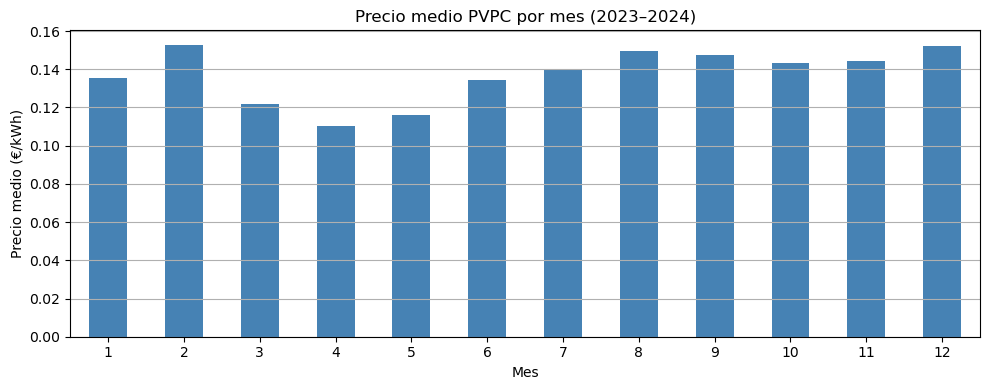

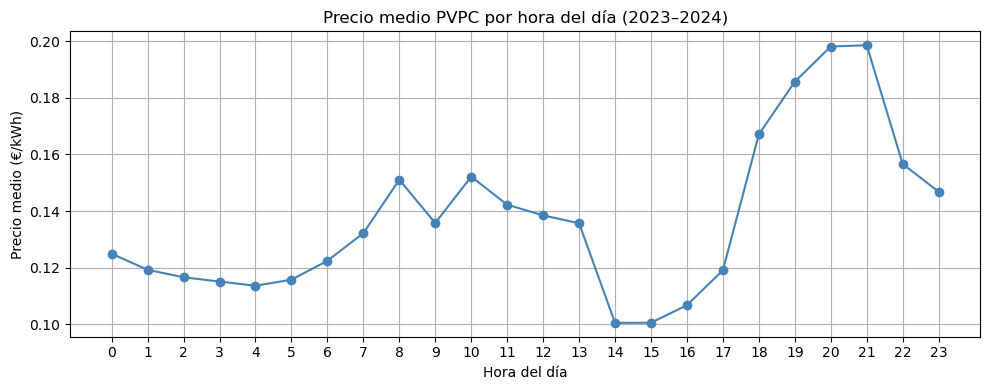

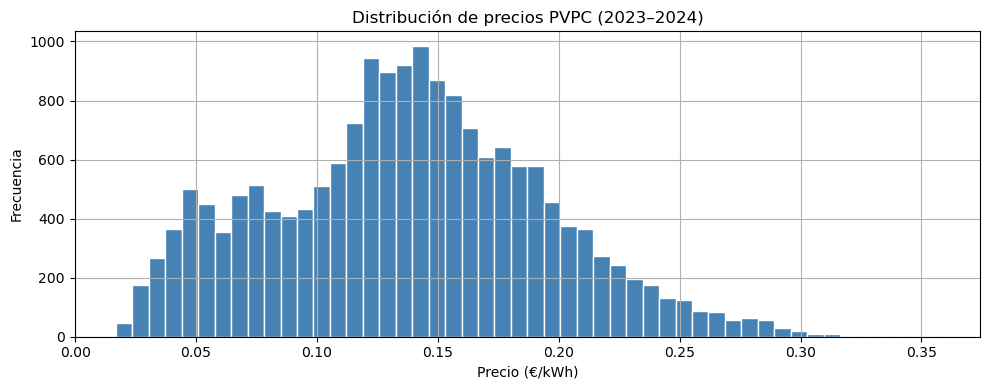

In [ ]:
import matplotlib.pyplot as plt

# Gráfica 1 evolución mensual 
monthly_avg = pvpc_prices.groupby("Month")["price_eur_kwh"].mean()

plt.figure(figsize=(10, 4))
monthly_avg.plot(kind="bar", color="steelblue")
plt.title("Precio medio PVPC por mes (2023–2024)")
plt.xlabel("Mes")
plt.ylabel("Precio medio (€/kWh)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Gráfica 2 precio medio por hora 
hourly_avg = pvpc_prices.groupby("Hour")["price_eur_kwh"].mean()

plt.figure(figsize=(10, 4))
hourly_avg.plot(marker="o", color="steelblue")
plt.title("Precio medio PVPC por hora del día (2023–2024)")
plt.xlabel("Hora del día")
plt.ylabel("Precio medio (€/kWh)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfica 3 distribución de precios 
plt.figure(figsize=(10, 4))
pvpc_prices["price_eur_kwh"].hist(bins=50, color="steelblue", edgecolor="white")
plt.title("Distribución de precios PVPC (2023–2024)")
plt.xlabel("Precio (€/kWh)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
pvpc_prices.sort_values("price_eur_kwh").head(5)

,datetime,price_eur_mwh,geo_id,geo_name,price_eur_kwh,Hour,Month,Date
7391,2023-11-04 23:00:00,16.84,8741,Península,0.01684,23,11,2023-11-04
4695,2023-07-15 16:00:00,19.42,8741,Península,0.01942,16,7,2023-07-15
14773,2024-09-07 14:00:00,19.54,8741,Península,0.01954,14,9,2024-09-07
7379,2023-11-04 11:00:00,19.74,8741,Península,0.01974,11,11,2023-11-04
14772,2024-09-07 13:00:00,20.30,8741,Península,0.02030,13,9,2024-09-07


In [17]:
pvpc_prices.sort_values("price_eur_kwh", ascending=False).head(5)

,datetime,price_eur_mwh,geo_id,geo_name,price_eur_kwh,Hour,Month,Date
571,2023-01-24 19:00:00,357.20,8741,Península,0.35720,19,1,2023-01-24
572,2023-01-24 20:00:00,354.70,8741,Península,0.35470,20,1,2023-01-24
715,2023-01-30 19:00:00,354.59,8741,Península,0.35459,19,1,2023-01-30
6930,2023-10-16 19:00:00,345.71,8741,Península,0.34571,19,10,2023-10-16
475,2023-01-20 19:00:00,344.68,8741,Península,0.34468,19,1,2023-01-20


In [18]:
pvpc_prices["Hour"] = pvpc_prices["datetime"].dt.hour

hourly_prices = (
    pvpc_prices
    .groupby("Hour")["price_eur_kwh"]
    .mean()
)

hourly_prices_df = hourly_prices.reset_index()
hourly_prices_df.columns = ["Hour", "avg_price_eur_kwh"]

In [19]:
hourly_prices_df.to_csv("../data/hourly_prices.csv", index=False)

In [ ]:

print("Token configurado correctamente.")
print("Procedemos a descargar datos de intensidad de CO2 de REE.")

Token configurado correctamente.
Procedemos a descargar datos de intensidad de CO2 de REE.


Descarga de datos de CO2 mes a mes 2023-2024 para poder implementar una mejora en el modelo sobre la huella de carbono. 

In [30]:
import requests
import pandas as pd
import calendar
import time

In [36]:
co2_records = []

for year in [2023, 2024]:
    for month in range(1, 13):
        start = f"{year}-{month:02d}-01T00:00"
        last_day = calendar.monthrange(year, month)[1]
        end = f"{year}-{month:02d}-{last_day}T23:59"

        url = (
            f"https://api.esios.ree.es/indicators/10355"
            f"?start_date={start}&end_date={end}"
            f"&geo_ids[]=8741"
        )

        response = requests.get(url, headers=headers)

        if response.status_code == 200:
            data = response.json()
            values = data["indicator"]["values"]
            for v in values:
                co2_records.append({
                    "datetime": v["datetime"],
                    "co2_tco2_mwh": v["value"]
                })
            print(f"OK — {year}-{month:02d} — {len(values)} registros")
        else:
            print(f"ERROR — {year}-{month:02d} — Status: {response.status_code}")

        time.sleep(0.5)

print(f"\nTotal registros descargados: {len(co2_records)}")

OK — 2023-01 — 8928 registros
OK — 2023-02 — 8064 registros
OK — 2023-03 — 8916 registros
OK — 2023-04 — 8640 registros
OK — 2023-05 — 8928 registros
OK — 2023-06 — 8640 registros
OK — 2023-07 — 8928 registros
OK — 2023-08 — 8928 registros
OK — 2023-09 — 8640 registros
OK — 2023-10 — 8940 registros
OK — 2023-11 — 8640 registros
OK — 2023-12 — 8928 registros
OK — 2024-01 — 8928 registros
OK — 2024-02 — 8352 registros
OK — 2024-03 — 8916 registros
OK — 2024-04 — 8640 registros
OK — 2024-05 — 8928 registros
OK — 2024-06 — 8640 registros
OK — 2024-07 — 8928 registros
OK — 2024-08 — 8928 registros
OK — 2024-09 — 8640 registros
OK — 2024-10 — 8940 registros
OK — 2024-11 — 8640 registros
OK — 2024-12 — 8928 registros

Total registros descargados: 210528


In [ ]:
co2_df = pd.DataFrame(co2_records)
co2_df["datetime"] = pd.to_datetime(co2_df["datetime"], utc=True)
co2_df["datetime"] = co2_df["datetime"].dt.tz_convert("Europe/Madrid")

# Eliminamos duplicados
co2_df = co2_df.drop_duplicates(subset="datetime")
co2_df = co2_df.sort_values("datetime").reset_index(drop=True)

co2_df = co2_df.set_index("datetime")
co2_df = co2_df.resample("h").mean()
co2_df = co2_df.dropna()
co2_df = co2_df.reset_index()

# Convertimos tCO2/MWh a gCO2/kWh multiplicando por 1000
co2_df["co2_g_kwh"] = co2_df["co2_tco2_mwh"] * 1000
co2_df = co2_df.drop(columns=["co2_tco2_mwh"])

print("Shape final:", co2_df.shape)
print("\nEstadísticas de intensidad de CO2 (gCO2/kWh):")
print(co2_df["co2_g_kwh"].describe().round(2))

display(co2_df.head())

co2_df.to_csv("../data/co2_intensity_2023_2024.csv", index=False)
print("\nArchivo guardado: co2_intensity_2023_2024.csv")

Shape final: (17544, 2)

Estadísticas de intensidad de CO2 (gCO2/kWh):
count    17544.00
mean        89.14
std         38.79
min         25.09
25%         58.91
50%         80.58
75%        112.10
max        245.57
Name: co2_g_kwh, dtype: float64


,datetime,co2_g_kwh
0,2023-01-01 00:00:00+01:00,69.416094
1,2023-01-01 01:00:00+01:00,78.661453
2,2023-01-01 02:00:00+01:00,82.035862
3,2023-01-01 03:00:00+01:00,83.748215
4,2023-01-01 04:00:00+01:00,85.059920



Archivo guardado: co2_intensity_2023_2024.csv


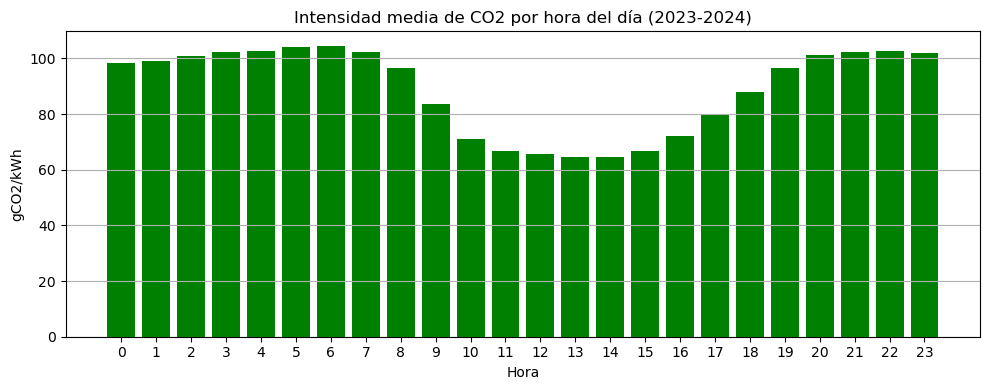


Hora con menor intensidad de CO2:
  13:00 — 64.67 gCO2/kWh
Hora con mayor intensidad de CO2:
  6:00 — 104.54 gCO2/kWh


In [38]:
import matplotlib.pyplot as plt

co2_df["hour"] = co2_df["datetime"].dt.hour
co2_df["month"] = co2_df["datetime"].dt.month

# CO2 medio por hora del día
hourly_co2 = co2_df.groupby("hour")["co2_g_kwh"].mean()

plt.figure(figsize=(10, 4))
plt.bar(hourly_co2.index, hourly_co2.values, color="green")
plt.title("Intensidad media de CO2 por hora del día (2023-2024)")
plt.xlabel("Hora")
plt.ylabel("gCO2/kWh")
plt.xticks(range(0, 24))
plt.grid(axis="y")
plt.tight_layout()
plt.show()

print("\nHora con menor intensidad de CO2:")
print(f"  {hourly_co2.idxmin()}:00 — {round(hourly_co2.min(), 2)} gCO2/kWh")
print("Hora con mayor intensidad de CO2:")
print(f"  {hourly_co2.idxmax()}:00 — {round(hourly_co2.max(), 2)} gCO2/kWh")